## Assignment 7: Pandas Fundementals

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

### 1) Use pandas to read_csv

In [12]:
df = pd.read_csv('http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120108 entries, 0 to 120107
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   time       120108 non-null  object 
 1   latitude   120108 non-null  float64
 2   longitude  120108 non-null  float64
 3   depth      120107 non-null  float64
 4   mag        120065 non-null  float64
 5   magType    120065 non-null  object 
 6   nst        59688 non-null   float64
 7   gap        94935 non-null   float64
 8   dmin       85682 non-null   float64
 9   rms        119716 non-null  float64
 10  net        120108 non-null  object 
 11  id         120108 non-null  object 
 12  updated    120108 non-null  object 
 13  place      120108 non-null  object 
 14  type       120108 non-null  object 
dtypes: float64(8), object(7)
memory usage: 13.7+ MB


In [21]:
df.shape

(120108, 15)

In [17]:
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type
0,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,ak11155107,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake
1,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,nn00436847,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake
2,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,ak11151142,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake
3,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,ak11151135,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake
4,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,ci37171541,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake


In [19]:
df['time']

0         2014-01-31 23:53:37.000
1         2014-01-31 23:48:35.452
2         2014-01-31 23:47:24.000
3         2014-01-31 23:30:54.000
4         2014-01-31 23:30:52.210
                   ...           
120103    2014-12-01 00:10:16.000
120104    2014-12-01 00:09:39.000
120105    2014-12-01 00:09:25.350
120106    2014-12-01 00:05:54.000
120107    2014-12-01 00:04:05.000
Name: time, Length: 120108, dtype: object

In [29]:
df['id']

0         ak11155107
1         nn00436847
2         ak11151142
3         ak11151135
4         ci37171541
             ...    
120103    ak11453391
120104    ak11453395
120105    nc72358451
120106    ak11453390
120107    ak11453389
Name: id, Length: 120108, dtype: object

### 2) Date collums identified as dates and earthquake ID

In [35]:
df = pd.read_csv(
    'http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv',
    index_col='id',
    parse_dates=['time', 'updated']
)

In [36]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120108 entries, ak11155107 to ak11453389
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype              
---  ------     --------------   -----              
 0   time       120108 non-null  datetime64[ns]     
 1   latitude   120108 non-null  float64            
 2   longitude  120108 non-null  float64            
 3   depth      120107 non-null  float64            
 4   mag        120065 non-null  float64            
 5   magType    120065 non-null  object             
 6   nst        59688 non-null   float64            
 7   gap        94935 non-null   float64            
 8   dmin       85682 non-null   float64            
 9   rms        119716 non-null  float64            
 10  net        120108 non-null  object             
 11  updated    120108 non-null  datetime64[ns, UTC]
 12  place      120108 non-null  object             
 13  type       120108 non-null  object             
dtypes: datetime64[ns, UTC](1), d

### 3) Describe for basic stats

In [51]:
df = pd.read_csv('http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv')

In [52]:
df.describe()

,latitude,longitude,depth,mag,nst,gap,dmin,rms
count,120108.000000,120108.000000,120107.000000,120065.000000,59688.000000,94935.000000,85682.000000,119716.000000
mean,38.399579,-99.961402,28.375029,1.793958,17.878284,124.048978,0.893198,0.358174
std,21.938258,82.996858,62.215416,1.343466,14.911369,68.518595,2.903966,0.364046
min,-73.462000,-179.998900,-9.900000,-0.970000,0.000000,9.000000,0.000000,0.000000
25%,34.228917,-147.742025,4.100000,0.820000,8.000000,74.000000,0.020760,0.070000
50%,38.805300,-120.832000,9.200000,1.400000,14.000000,107.000000,0.073670,0.200000
75%,53.889500,-116.068100,22.880000,2.400000,22.000000,155.000000,0.447000,0.590000
max,86.651400,179.998000,697.360000,8.200000,365.000000,356.400000,64.498000,8.460000


In [53]:
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type
0,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,ak11155107,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake
1,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,nn00436847,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake
2,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,ak11151142,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake
3,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,ak11151135,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake
4,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,ci37171541,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake


### 4) Use nlargest to get top 20

In [49]:
df = pd.read_csv('http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv')

In [59]:
df.nlargest(n=20, columns='mag')

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type
37371,2014-04-01 23:46:47.260,-19.6097,-70.7691,25.00,8.2,mww,NaN,23.0,0.609,0.66,us,usc000nzvd,2015-07-30T16:24:51.223Z,"94km NW of Iquique, Chile",earthquake
50562,2014-06-23 20:53:09.700,51.8486,178.7352,109.00,7.9,mww,NaN,22.0,0.133,0.71,us,usc000rki5,2015-04-18T21:54:08.699Z,"19km SE of Little Sitkin Island, Alaska",earthquake
36918,2014-04-03 02:43:13.110,-20.5709,-70.4931,22.40,7.7,mww,NaN,44.0,1.029,0.82,us,usc000p27i,2015-06-06T07:31:05.755Z,"53km SW of Iquique, Chile",earthquake
33808,2014-04-12 20:14:39.300,-11.2701,162.1481,22.56,7.6,mww,NaN,13.0,2.828,0.71,us,usc000phx5,2015-04-18T21:54:27.398Z,"93km SSE of Kirakira, Solomon Islands",earthquake
31496,2014-04-19 13:28:00.810,-6.7547,155.0241,43.37,7.5,mww,NaN,16.0,3.820,1.25,us,usb000pr89,2015-04-18T21:54:18.633Z,"70km SW of Panguna, Papua New Guinea",earthquake
33537,2014-04-13 12:36:19.230,-11.4633,162.0511,39.00,7.4,mww,NaN,17.0,2.885,1.00,us,usc000piqj,2015-08-13T19:29:13.018Z,"112km S of Kirakira, Solomon Islands",earthquake
95913,2014-10-14 03:51:34.460,12.5262,-88.1225,40.00,7.3,mww,NaN,18.0,1.078,0.70,us,usb000slwn,2015-08-13T19:35:02.679Z,"74km S of Intipuca, El Salvador",earthquake
31850,2014-04-18 14:27:24.920,17.3970,-100.9723,24.00,7.2,mww,NaN,46.0,2.250,1.20,us,usb000pq41,2015-08-13T19:30:39.599Z,"33km ESE of Petatlan, Mexico",earthquake
34318,2014-04-11 07:07:23.130,-6.5858,155.0485,60.53,7.1,mww,NaN,21.0,3.729,0.88,us,usc000pft9,2014-07-01T02:37:56.000Z,"56km WSW of Panguna, Papua New Guinea",earthquake
106285,2014-11-15 02:31:41.720,1.8929,126.5217,45.00,7.1,mww,NaN,18.0,1.397,0.71,us,usc000sxh8,2015-03-20T18:42:02.735Z,"154km NW of Kota Ternate, Indonesia",earthquake


### 5) Extract the stat or country using pandas

In [61]:
df['country'] = df.place.str.split(', ').str[-1]
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,country
0,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,ak11155107,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake,Alaska
1,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,nn00436847,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake,Nevada
2,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,ak11151142,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake,Alaska
3,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,ak11151135,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake,Alaska
4,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,ci37171541,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake,Mexico


### 6) Display each unique value

In [63]:
list(df.groupby('country').groups.keys())

['',
 '1km ENE of Quarry at VICTORVILLE',
 '1km NNE of Quarry at BORON',
 '3km WSW of Quarry at CUSHENBURY',
 'Afghanistan',
 'Alabama',
 'Alaska',
 'Alaska Peninsula',
 'Albania',
 'Algeria',
 'American Samoa',
 'Angola',
 'Anguilla',
 'Antarctica',
 'Argentina',
 'Arizona',
 'Arkansas',
 'Aruba',
 'Ascension Island region',
 'Australia',
 'Azerbaijan',
 'Azores Islands region',
 'Azores-Cape St. Vincent Ridge',
 'Balleny Islands region',
 'Banda Sea',
 'Bangladesh',
 'Barbados',
 'Barbuda',
 'Bay of Bengal',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Bouvet Island',
 'Bouvet Island region',
 'Brazil',
 'British Indian Ocean Territory',
 'British Virgin Islands',
 'Burma',
 'Burundi',
 'CA',
 'California',
 'Canada',
 'Cape Verde',
 'Carlsberg Ridge',
 'Cayman Islands',
 'Celebes Sea',
 'Central Alaska',
 'Central California',
 'Central East Pacific Rise',
 'Central Mid-Atlantic Ridge',
 'Chagos Archipelago region',
 'Chile',
 'China',
 'Christmas Island',
 'Colom

### 7) Filtered dataset only earthquacked mag 4 or larger

In [64]:
df_all = df                 
df_small = df[df.mag < 4]    
df = df[df.mag >= 4]         

### 8) Make bar chart

<Axes: xlabel='country'>

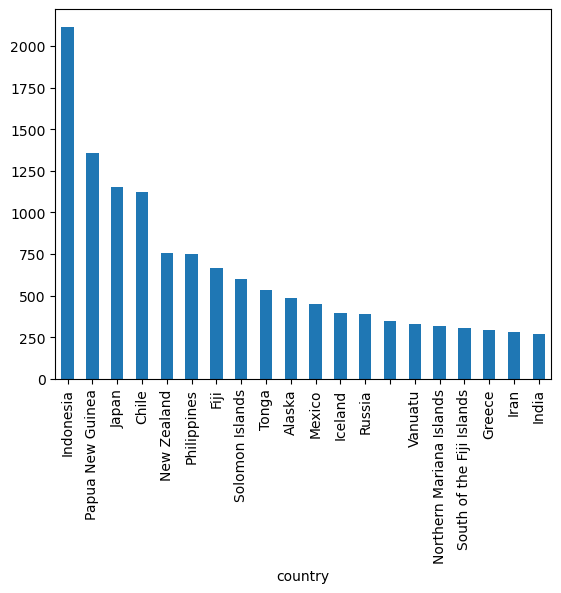

In [65]:
df.groupby('country').mag.count().nlargest(20).plot(kind='bar')

In [67]:
top5 = df.groupby('country').mag.count().nlargest(5)

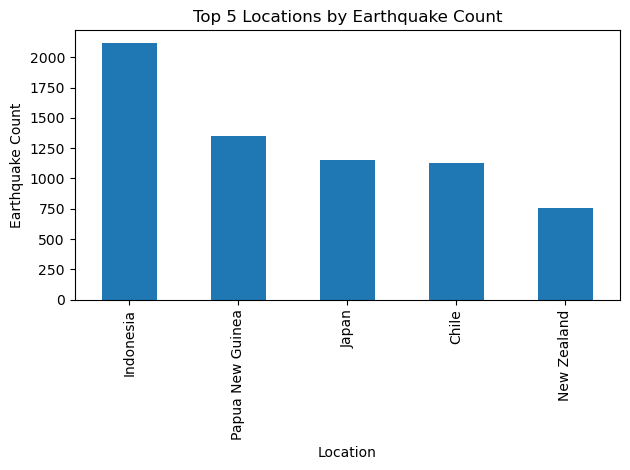

In [68]:
top5.plot(kind='bar')
plt.xlabel('Location')
plt.ylabel('Earthquake Count')
plt.title('Top 5 Locations by Earthquake Count')
plt.tight_layout()  
plt.show()

### 9) Make histogram

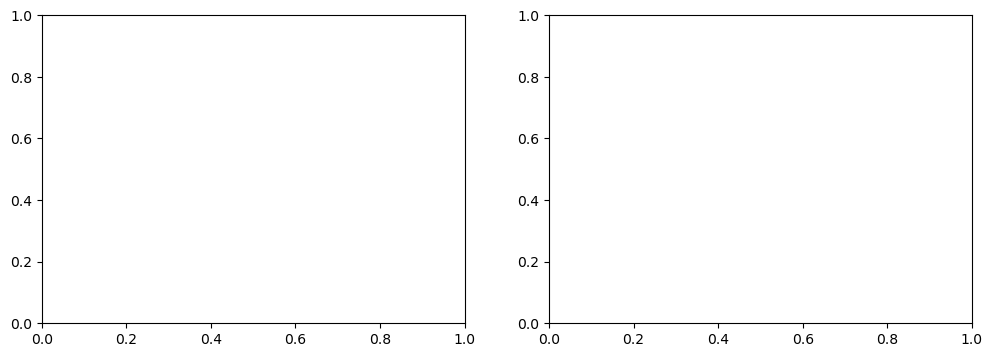

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

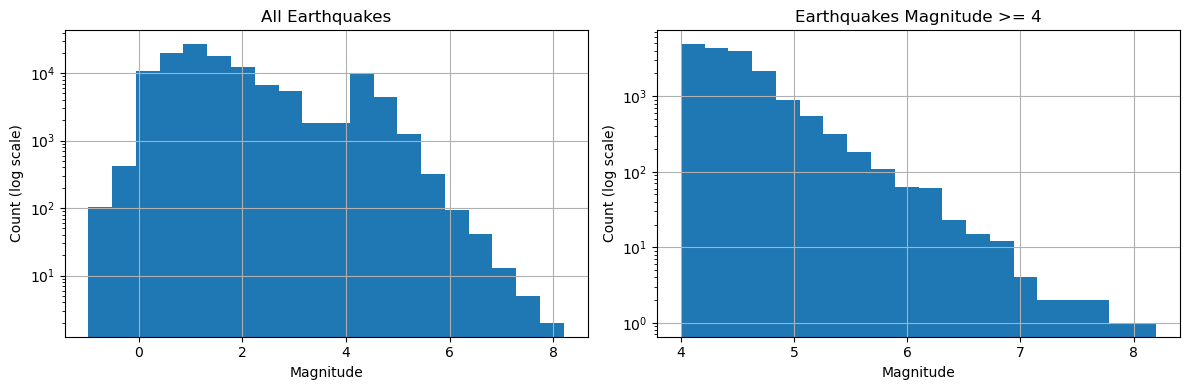

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_all['mag'].hist(bins=20, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('All Earthquakes')
axes[0].set_xlabel('Magnitude')
axes[0].set_ylabel('Count (log scale)')

df['mag'].hist(bins=20, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Earthquakes Magnitude >= 4')
axes[1].set_xlabel('Magnitude')
axes[1].set_ylabel('Count (log scale)')

plt.tight_layout()
plt.show()

### Obervations

Plot one (unfiltered) shows that smaller magintude earthquackes occur more frequently than the filtered plot (mag > 4). Teh number or earhtquackes reduces significantly. it also appears farm more linear, there is a strong relashionship between large earthquackes and low occurance.  

### 10) Visualize the locations of the earthquackes

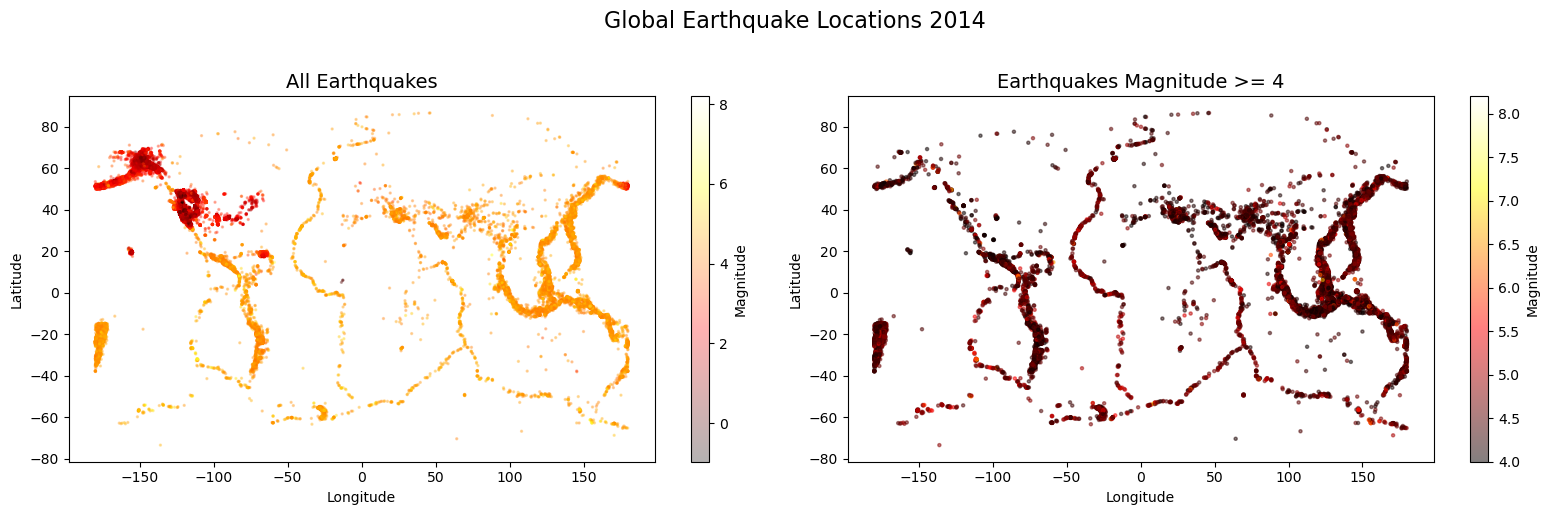

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

scatter1 = axes[0].scatter(df_all['longitude'], df_all['latitude'],
                           c=df_all['mag'],
                           cmap='hot',
                           alpha=0.3,
                           s=2)
axes[0].set_title('All Earthquakes', fontsize=14)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
plt.colorbar(scatter1, ax=axes[0], label='Magnitude')

scatter2 = axes[1].scatter(df['longitude'], df['latitude'],
                           c=df['mag'],
                           cmap='hot',
                           alpha=0.5,
                           s=5)
axes[1].set_title('Earthquakes Magnitude >= 4', fontsize=14)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
plt.colorbar(scatter2, ax=axes[1], label='Magnitude')

plt.suptitle('Global Earthquake Locations 2014', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Observations, difference? 

The unfiltered plot shows North-Western Americas have densely clustered dark red, meaning a frequency of low magnitude earthquakes (2). However, when sorted to mag>=4, the distribution spreads out more globally. There are clearly marked out dark red spots along the tectonic plates of South and North-East Asia, and the East coastline of Latin America, measuring at higher magnitudes (4-4.5). Previously not strongly outlined in the first unfiltered plot.   